# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

#### My top data set
1. CDC Diabetes Health Indicators UCI Machine Learning Repository (sourced from BRFSS)  
    - [dataset link](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators) 
    - This dataset identifies risk factors associated with diabetes such as BMI, High Blood Pressure, Smoking and others across a large population.

#### WHO

The audience for this respective dataset could be the government. More specifically, the findings could be presented to the State Department of Public Health or possibly the US Department of Health and Human services. Why would this be the appropriate audience? They control the budget for preventative health programs and/or govern policies for public health in a variety of aways. Finding meaningful correlations could help identify the appropriate preventative programs that can reduce the prevalant of diabetes in society. 


#### WHAT

The action requested from the government - Shift the budget from generic "eat healthy" billboards to targeted blood pressure screening and accessible gym/nutrition vouchers in specific zip codes and/or other possible actions as correlations in the data are identified. 

#### HOW

Useing data and visualizations to competl the audience would be the best way. For example identifying that BMI alone increases diabetes risk moderately, the combination of HighBP + Low Income + High BMI creates a near-vertical spike in diabetes probability. Showcasing that financial barriers, behaviors, and other conditions could help sell the audience on funding the proper preventative programs to make an impact in reducing diabetes in the population. 


# 3. Homework - work with your own data

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [5]:
import warnings
# Configs
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')


# Load the CSV and get dataframe info
df = pd.read_csv('cdc-diabetes-health-indicators/diabetes_binary_health_indicators_BRFSS2015.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
# head of the top 10 records
df.head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [7]:
# random sample of 10 records
df.sample(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
250256,1.0,0.0,1.0,1.0,48.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,5.0,6.0,6.0
120399,0.0,0.0,1.0,1.0,25.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,7.0,0.0,0.0,10.0,4.0,5.0
122833,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,10.0,3.0,4.0
37904,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,0.0,30.0,0.0,0.0,9.0,6.0,7.0
42588,0.0,1.0,1.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,13.0,6.0,6.0
234874,0.0,1.0,1.0,1.0,33.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,1.0,1.0,13.0,6.0,8.0
205849,0.0,0.0,0.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
51174,0.0,1.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,7.0
219492,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,3.0,15.0,3.0,0.0,1.0,6.0,5.0,6.0
112579,0.0,1.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,7.0,6.0,8.0


In [8]:
# Check for nulls and output back to a dataframe
df.isna().any().to_frame().reset_index().rename(columns={'index': 'features', 0: 'any_nulls'})

,features,any_nulls
0,Diabetes_binary,False
1,HighBP,False
2,HighChol,False
3,CholCheck,False
4,BMI,False
5,Smoker,False
6,Stroke,False
7,HeartDiseaseorAttack,False
8,PhysActivity,False
9,Fruits,False


In [9]:
df['Age'].value_counts().sort_index().to_frame()

,count
Age,
1.0,5700
2.0,7598
3.0,11123
4.0,13823
5.0,16157
6.0,19819
7.0,26314
8.0,30832
9.0,33244


In [10]:
# Describe the data frame
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [11]:
# Count the instance of duplicate records.
df.duplicated().sum()

np.int64(24206)

In [12]:
# Get the mean, median, and mode of each columns
means = df.mean(numeric_only=True)
medians = df.median(numeric_only=True)
modes = df.mode().iloc[0] # Pandas mode function can return multiple modes, this only takes the first one. 

# store in a summary DF
summary_df = pd.DataFrame([means, medians, modes], index=['mean', 'median', 'mode'])
summary_df


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
mean,0.139333,0.429001,0.424121,0.96267,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.81142,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
median,0.000000,0.000000,0.000000,1.00000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
mode,0.000000,0.000000,0.000000,1.00000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,9.000000,6.000000,8.000000


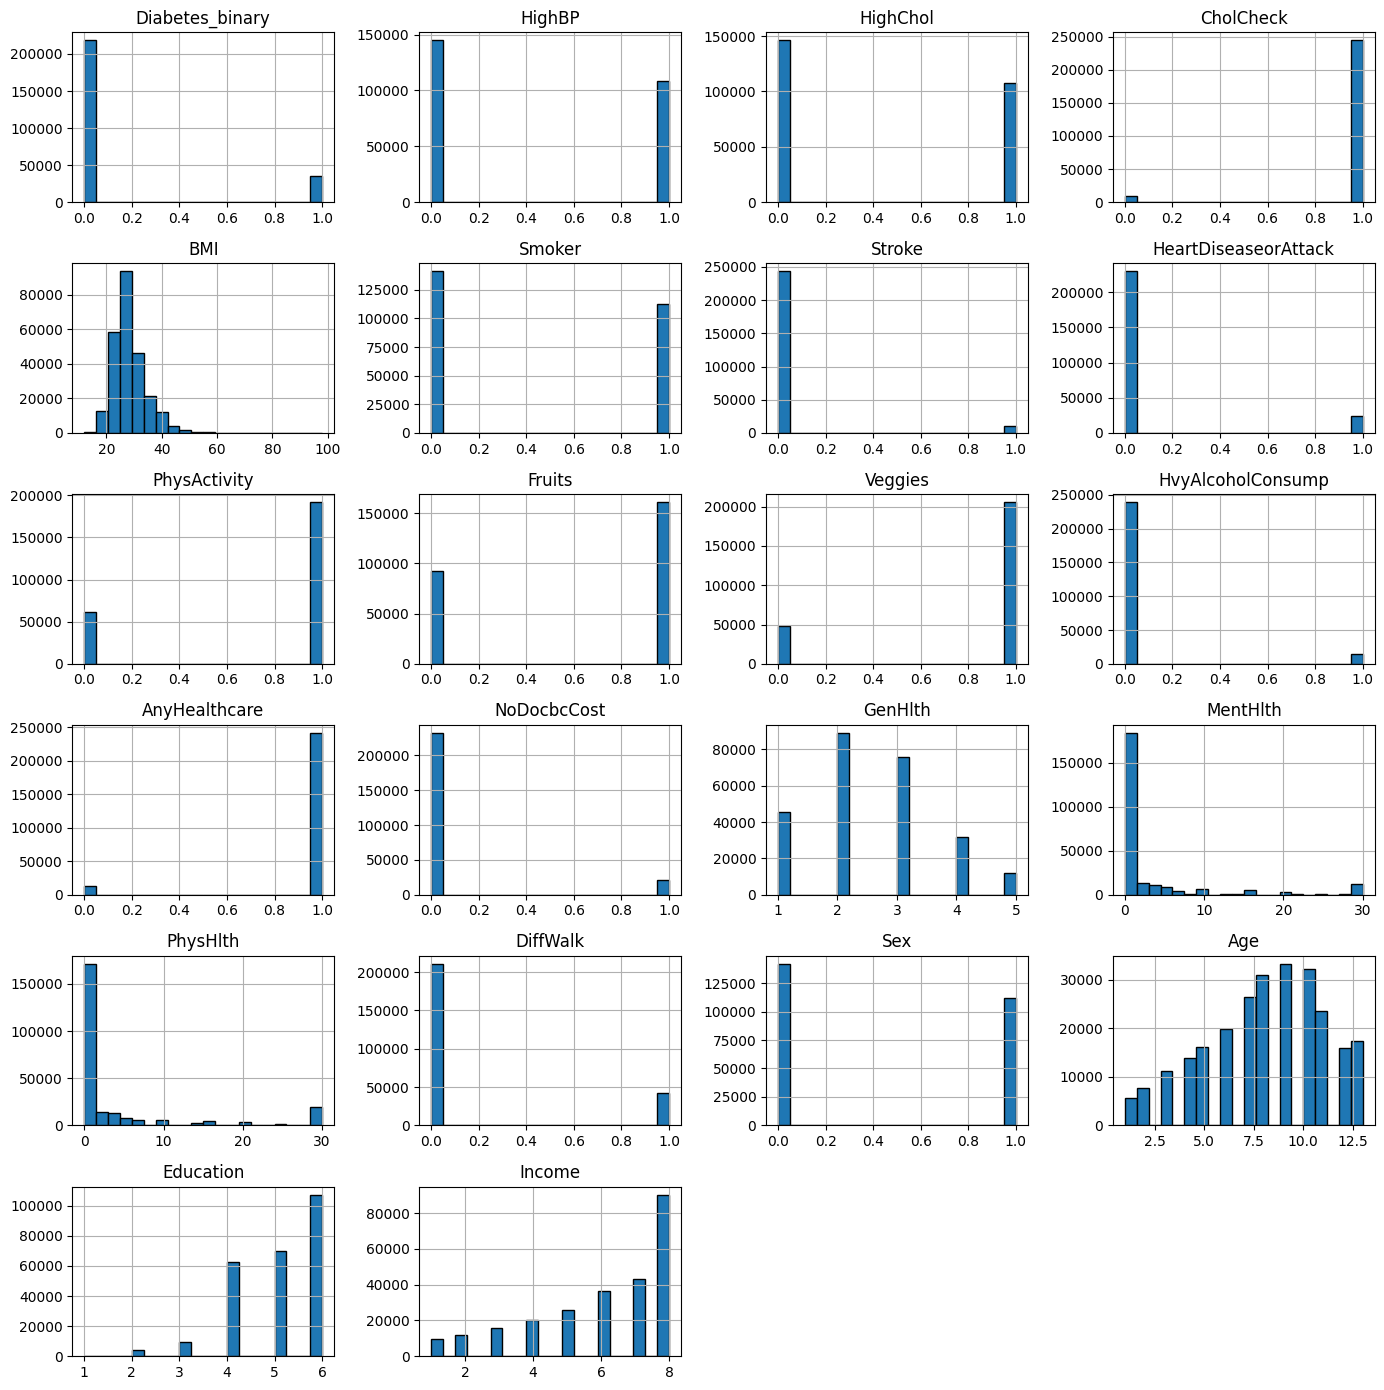

In [13]:
# Plot histograms of the columns in the dataframe. 
df.hist(figsize=(14, 14), layout=(6, 4), bins=20, edgecolor='black')
plt.tight_layout()
None

In [14]:
# Identify any categorical columns to hot encode and put them in a list. 
# The output below seems like all features have already been encoded. 

categorical_cols = df.select_dtypes(include=['object', 'category'])
print(categorical_cols.columns.tolist())

[]


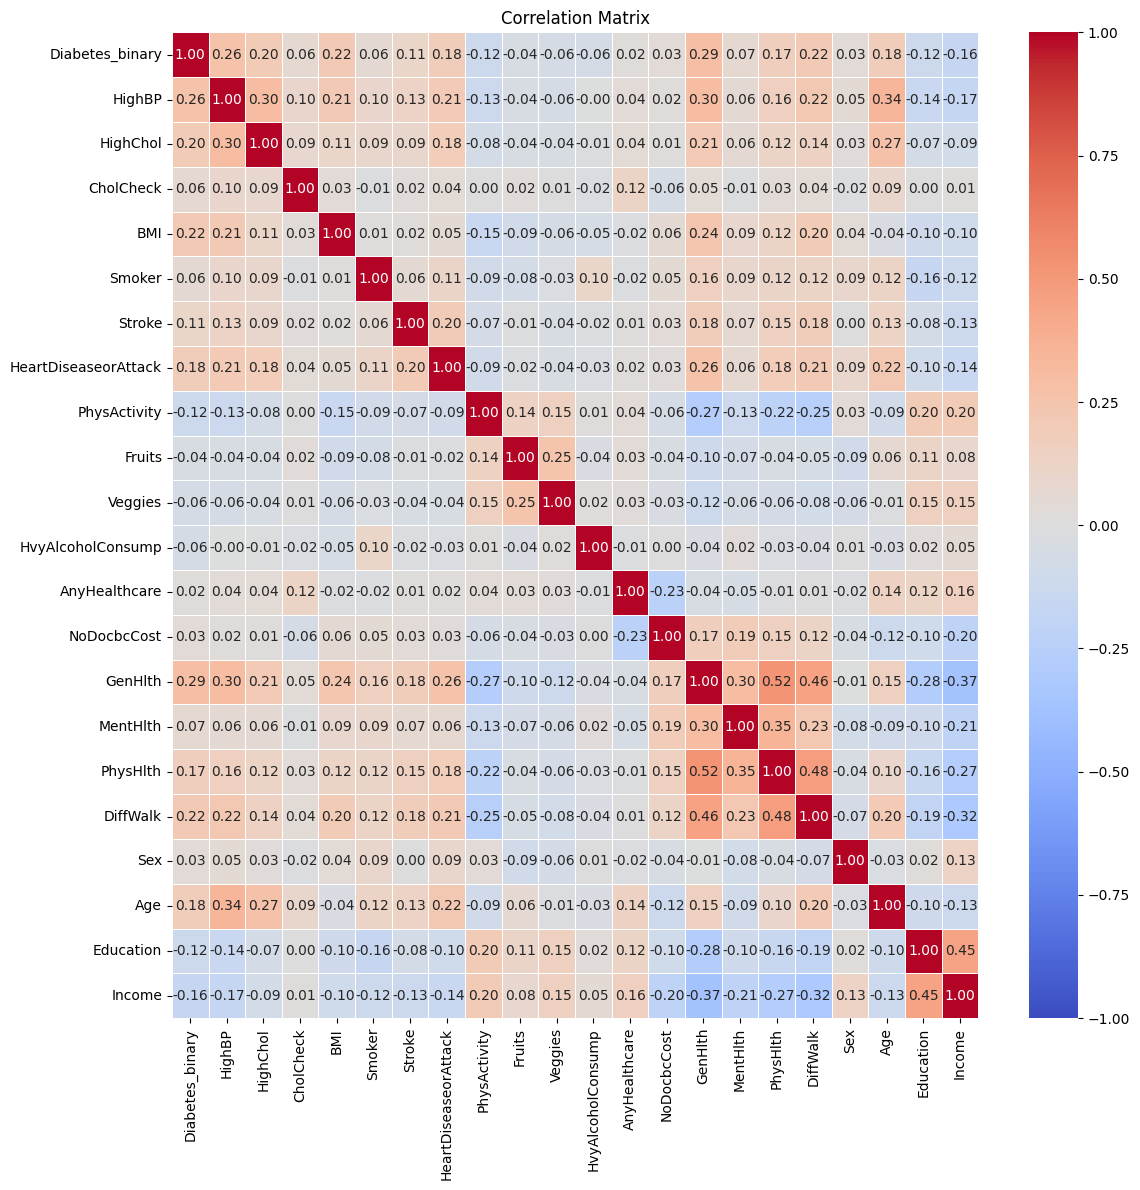

In [ ]:
# Create and render correlation matrix accross the entire df

corr_matrix = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5, linecolor='white', fmt=".2f",)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## My High Level Answers & Conclusions

- **Summarize the datasets using info() and describe()**
    - Done above. 
- **Are there any duplicate rows?**
    - There are 24,206 duplicate rows. Duplicates within the column 
- **Are there any duplicate values in a given column (when this would be inappropriate?)**
    - None of the columns are IDs or another value possibly indicating the possibility of a duplicate valid to remove. 
- **What are the mean, median, and mode of each column?**
    - To see the mean, median, and mode please refer to the `summary_df` variable in the code above. 
- **Are there any missing or null values?**
    - There do not seem to be nulls/missing values. The creators of the dataset have eliminated nulls. 
    - **Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?**
        - imputation strategies or simply dropping the columns would both be viable paths to test. 
- **Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)**
    - given this was survey data that seems to have been cleaned
- **Encode any categorical variables (e.g. with one-hot encoding.)**
    - Age was converted into a categorical or more specifically an ordinal feature. It has been converted into groupings of ages with an integer ranging from 1 - 13 representing the various groupings from 18-80.
### Conclusions:
- **Are the data usable?  If not, find some new data!**
    - The data set is clean, encoded, contains some duplicates and a few outliers, but is definitively usable. 
- **Do you need to modify or correct the data in some way?**
    - There may need to be deeper investigations into the outliers or fields that have imbalanced data. For example, there are few people in the dataset that have experienced a stroke, or fewer samples from participants of a younger age. Eliminating outliers and/or using resampling techniques to create a more balanced data set could be explored to improve predictive power and help reduce model variance due to noise. 
- **Is there any class imbalance?  (Categories that have many more items than other categories).**
    - Those with strokes are at an imbalance with those that have not had a stroke. This is expected. 
    - There is a significant imbalance between those that have a history of heart disease or attacks and those that do not. Expected in the data. 
    - The younger age groups are less represented than the older age groups. Seeing more of a left skew distribution here with a stronger represenetation in the middle-aged to older demographic. 
    - Those with lower education levels and income levels are not as represented as those with more education

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

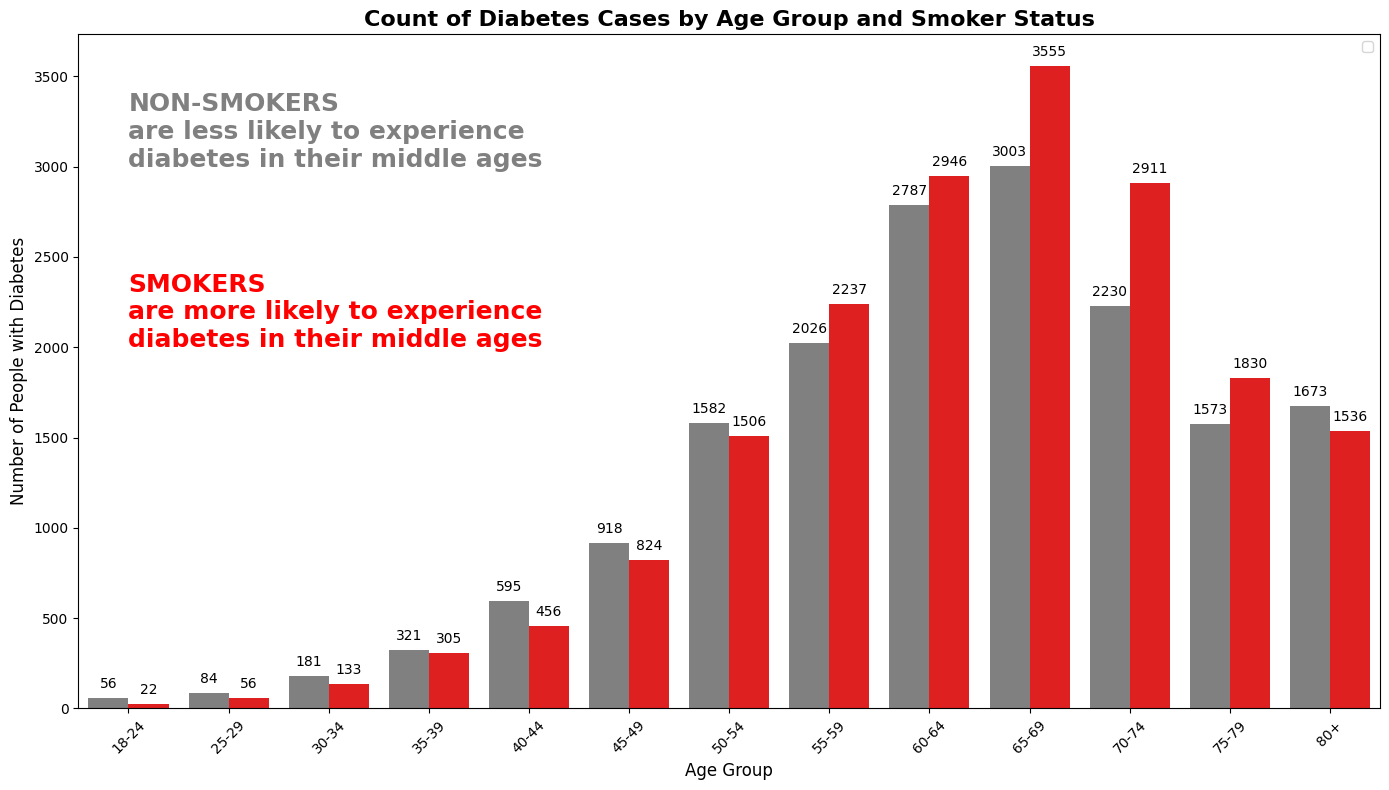

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the Map
age_map = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

# Filter and Group
diabetes_cases = df[df['Diabetes_binary'] == 1].groupby(['Age', 'Smoker']).size().reset_index(name='Count')

# Setup the Plot
plt.figure(figsize=(14, 8))
custom_palette = {0: 'gray', 1: 'red'}

# Create the Bar Plot
ax = sns.barplot(
    data=diabetes_cases, 
    x='Age', 
    y='Count', 
    hue='Smoker', 
    palette=custom_palette,
    legend=False
)

# --- KEY CHANGE: Apply the Map to the X-Axis ---
# We get the unique sorted ages from the data and map them to the labels
labels = [age_map[i] for i in sorted(diabetes_cases['Age'].unique())]
ax.set_xticklabels(labels)

# Add Annotations (The "What")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Formatting (The "Context")
plt.title('Count of Diabetes Cases by Age Group and Smoker Status', fontsize=16, weight='bold')
plt.ylabel('Number of People with Diabetes', fontsize=12)
plt.xlabel('Age Group', fontsize=12)

# Rotate x-axis labels to prevent overlapping
plt.xticks(rotation=45)

# Custom Text Annotations
plt.annotate('SMOKERS\nare more likely to experience\ndiabetes in their middle ages', 
             xy=(0, 300), xytext=(0, 2000), # Adjusted xytext slightly to fit new layout
             color='red', weight='bold', fontsize=18)

plt.annotate('NON-SMOKERS\nare less likely to experience\ndiabetes in their middle ages', 
             xy=(0, 300), xytext=(0, 3000),
             color='gray', weight='bold', fontsize=18)

plt.legend()
plt.tight_layout() # Ensures labels aren't cut off when saving
plt.show()